<h2 align="center" style="color:blue">Codebasics ML Course: Regression Project Exercise Solution</h2>

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split

 <h2 align='center'> Load DataSet </h2>

In [2]:
df = pd.read_excel('premiums_with_life_style.xlsx')
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()
print('Total no of rows and columns are: ',df.shape)
df.head()

Total no of rows and columns are:  (10000, 15)


,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


<h2 align = 'Center'> Explortory Data Analysis and Data Cleaning </h2>

### Handle Missing Values

In [3]:
df.isna().sum()

age                       0
gender                    0
region                    0
marital_status            0
physical_activity         0
stress_level              0
number_of_dependants      0
bmi_category              0
smoking_status            9
employment_status         7
income_level             18
income_lakhs              0
medical_history           0
insurance_plan            0
annual_premium_amount     0
dtype: int64

In [4]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
physical_activity        0
stress_level             0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### Handle Duplicate

In [5]:
df.duplicated().sum()

0

In [6]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9973.000000,9973.000000,9973.000000,9973.000000
mean,41.319362,3.195628,23.382232,19503.816705
std,58.044687,21.679565,32.334811,8898.079736
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11774.000000
50%,37.000000,2.000000,16.000000,19314.000000
75%,50.000000,3.000000,31.000000,26500.000000
max,1178.000000,456.000000,960.000000,45854.000000


### Numeric Column Analysis

#### UniVarite Analysis

In [7]:
numeric_cols  = df.select_dtypes(include=['float64','int64']).columns
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

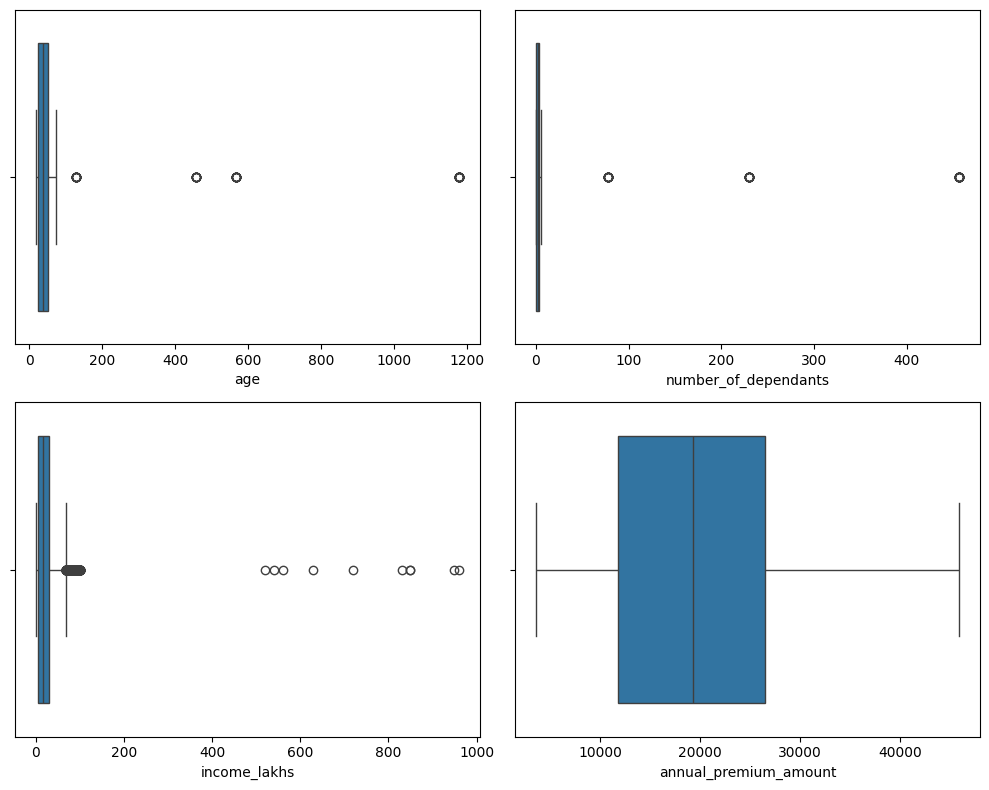

In [8]:
fig,axs  = plt.subplots(nrows=2,ncols=2,figsize=(10,8))

for i, col in enumerate(numeric_cols):
    ax = axs[i//2,i%2]
    sns.boxplot(x=df[col],ax=ax)
plt.tight_layout()
plt.show()

> There are outliers in age,number_of_dependants and income_lakhs column

### Outlier Treatment Age Column

In [9]:
df1 = df[df.age<=100]
df1.age.describe()

count    9915.000000
mean       37.743621
std        13.975462
min        18.000000
25%        24.000000
50%        37.000000
75%        50.000000
max        72.000000
Name: age, dtype: float64

### Outlier Treatment Number of Dependants Column

In [10]:
df1 = df1[df1['number_of_dependants'] <= 10]
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9868.000000,9868.000000,9868.000000,9868.000000
mean,37.756486,1.919133,23.411634,19511.417714
std,13.976822,1.503264,32.437621,8900.941540
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11776.250000
50%,37.000000,2.000000,16.000000,19327.500000
75%,50.000000,3.000000,31.000000,26505.250000
max,72.000000,5.000000,960.000000,45854.000000


### Outlier Treatment Income_Lakhs  Column

In [11]:
def get_iqr_bounds(col):
    Q1,Q3 = col.quantile([0.25,0.75])
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return lower_bound,upper_bound

lower,upper = get_iqr_bounds(df1['income_lakhs'])


In [12]:
lower,upper

(-31.5, 68.5)

In [13]:
df1[df1.income_lakhs>upper].shape

(694, 15)

There are many legitimate records that we will get rid of if we use IQR bounds method. Hence after discussion with business we decided to use a simple quantile bound 

In [14]:
quantile_threeshold = df1.income_lakhs.quantile(0.99)
quantile_threeshold

97.0

In [15]:
df1 = df1[df1['income_lakhs']<=quantile_threeshold]
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,9792.000000,9792.000000,9792.000000,9792.000000
mean,37.756638,1.920547,22.168199,19490.845384
std,13.971721,1.502872,21.629748,8900.055780
min,18.000000,0.000000,1.000000,3582.000000
25%,24.000000,0.000000,6.000000,11756.750000
50%,37.000000,2.000000,16.000000,19309.500000
75%,50.000000,3.000000,31.000000,26485.250000
max,72.000000,5.000000,97.000000,45854.000000


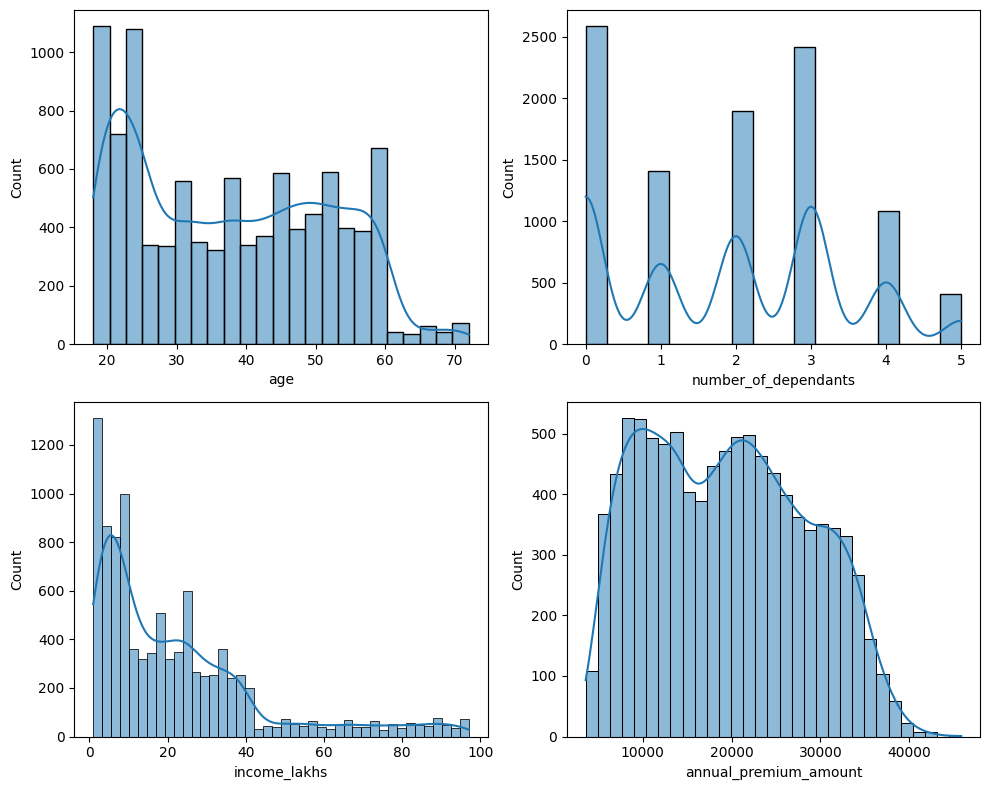

In [16]:
fig,axs = plt.subplots(nrows=2,ncols=2,figsize=(10,8))
for i,col in enumerate(numeric_cols):
    ax = axs[i//2,i%2]
    sns.histplot(df1[col],ax=ax,kde=True)

plt.tight_layout()
plt.show()

In [17]:
df1.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,<10L,9,No Disease,Bronze,8459
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,<10L,9,Thyroid,Silver,21685
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,10L - 25L,13,High blood pressure & Heart disease,Bronze,15984


### Bivariate Analysis: Numeric Columns

In [18]:
numeric_cols

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

In [19]:
print('number_of_dependants' in df1.columns)

True


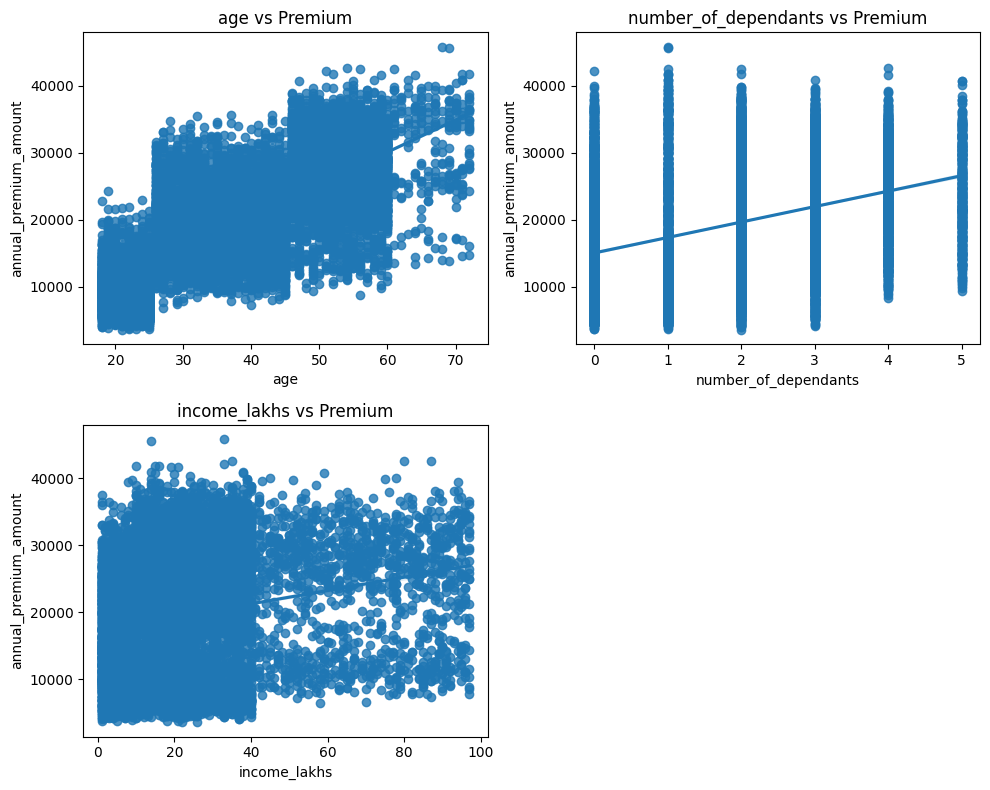

In [20]:
numeric_features = ['age', 'number_of_dependants', 'income_lakhs']

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i, col in enumerate(numeric_features):
    ax = axes[i//2, i%2]
    sns.regplot(x=df1[col], y=df1['annual_premium_amount'], ax=ax)
    ax.set_title(f"{col} vs Premium")

fig.delaxes(axes[1][1])

plt.tight_layout()
plt.show()

### 2. Categorical Columns

In [21]:
categorical_cols = ['gender','region','marital_status','physical_activity','stress_level','bmi_category','smoking_status','employment_status','income_level','medical_history']
for col in categorical_cols:
    print(f'column : {col} = {df1[col].unique()}')

column : gender = ['Female' 'Male']
column : region = ['Southeast' 'Northeast' 'Southwest' 'Northwest']
column : marital_status = ['Unmarried' 'Married']
column : physical_activity = ['Medium' 'Low' 'High']
column : stress_level = ['Medium' 'High' 'Low']
column : bmi_category = ['Normal' 'Overweight' 'Obesity' 'Underweight']
column : smoking_status = ['No Smoking' 'Occasional' 'Regular']
column : employment_status = ['Self-Employed' 'Freelancer' 'Salaried']
column : income_level = ['25L - 40L' '10L - 25L' '<10L' '> 40L']
column : medical_history = ['High blood pressure' 'No Disease' 'Thyroid'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid' 'Diabetes'
 'Heart disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease']


### UniVarite Analysis

In [22]:
df1.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,High blood pressure,Gold,27944
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,No Disease,Silver,21108


In [23]:
df1.gender.value_counts()

gender
Female    5855
Male      3937
Name: count, dtype: int64

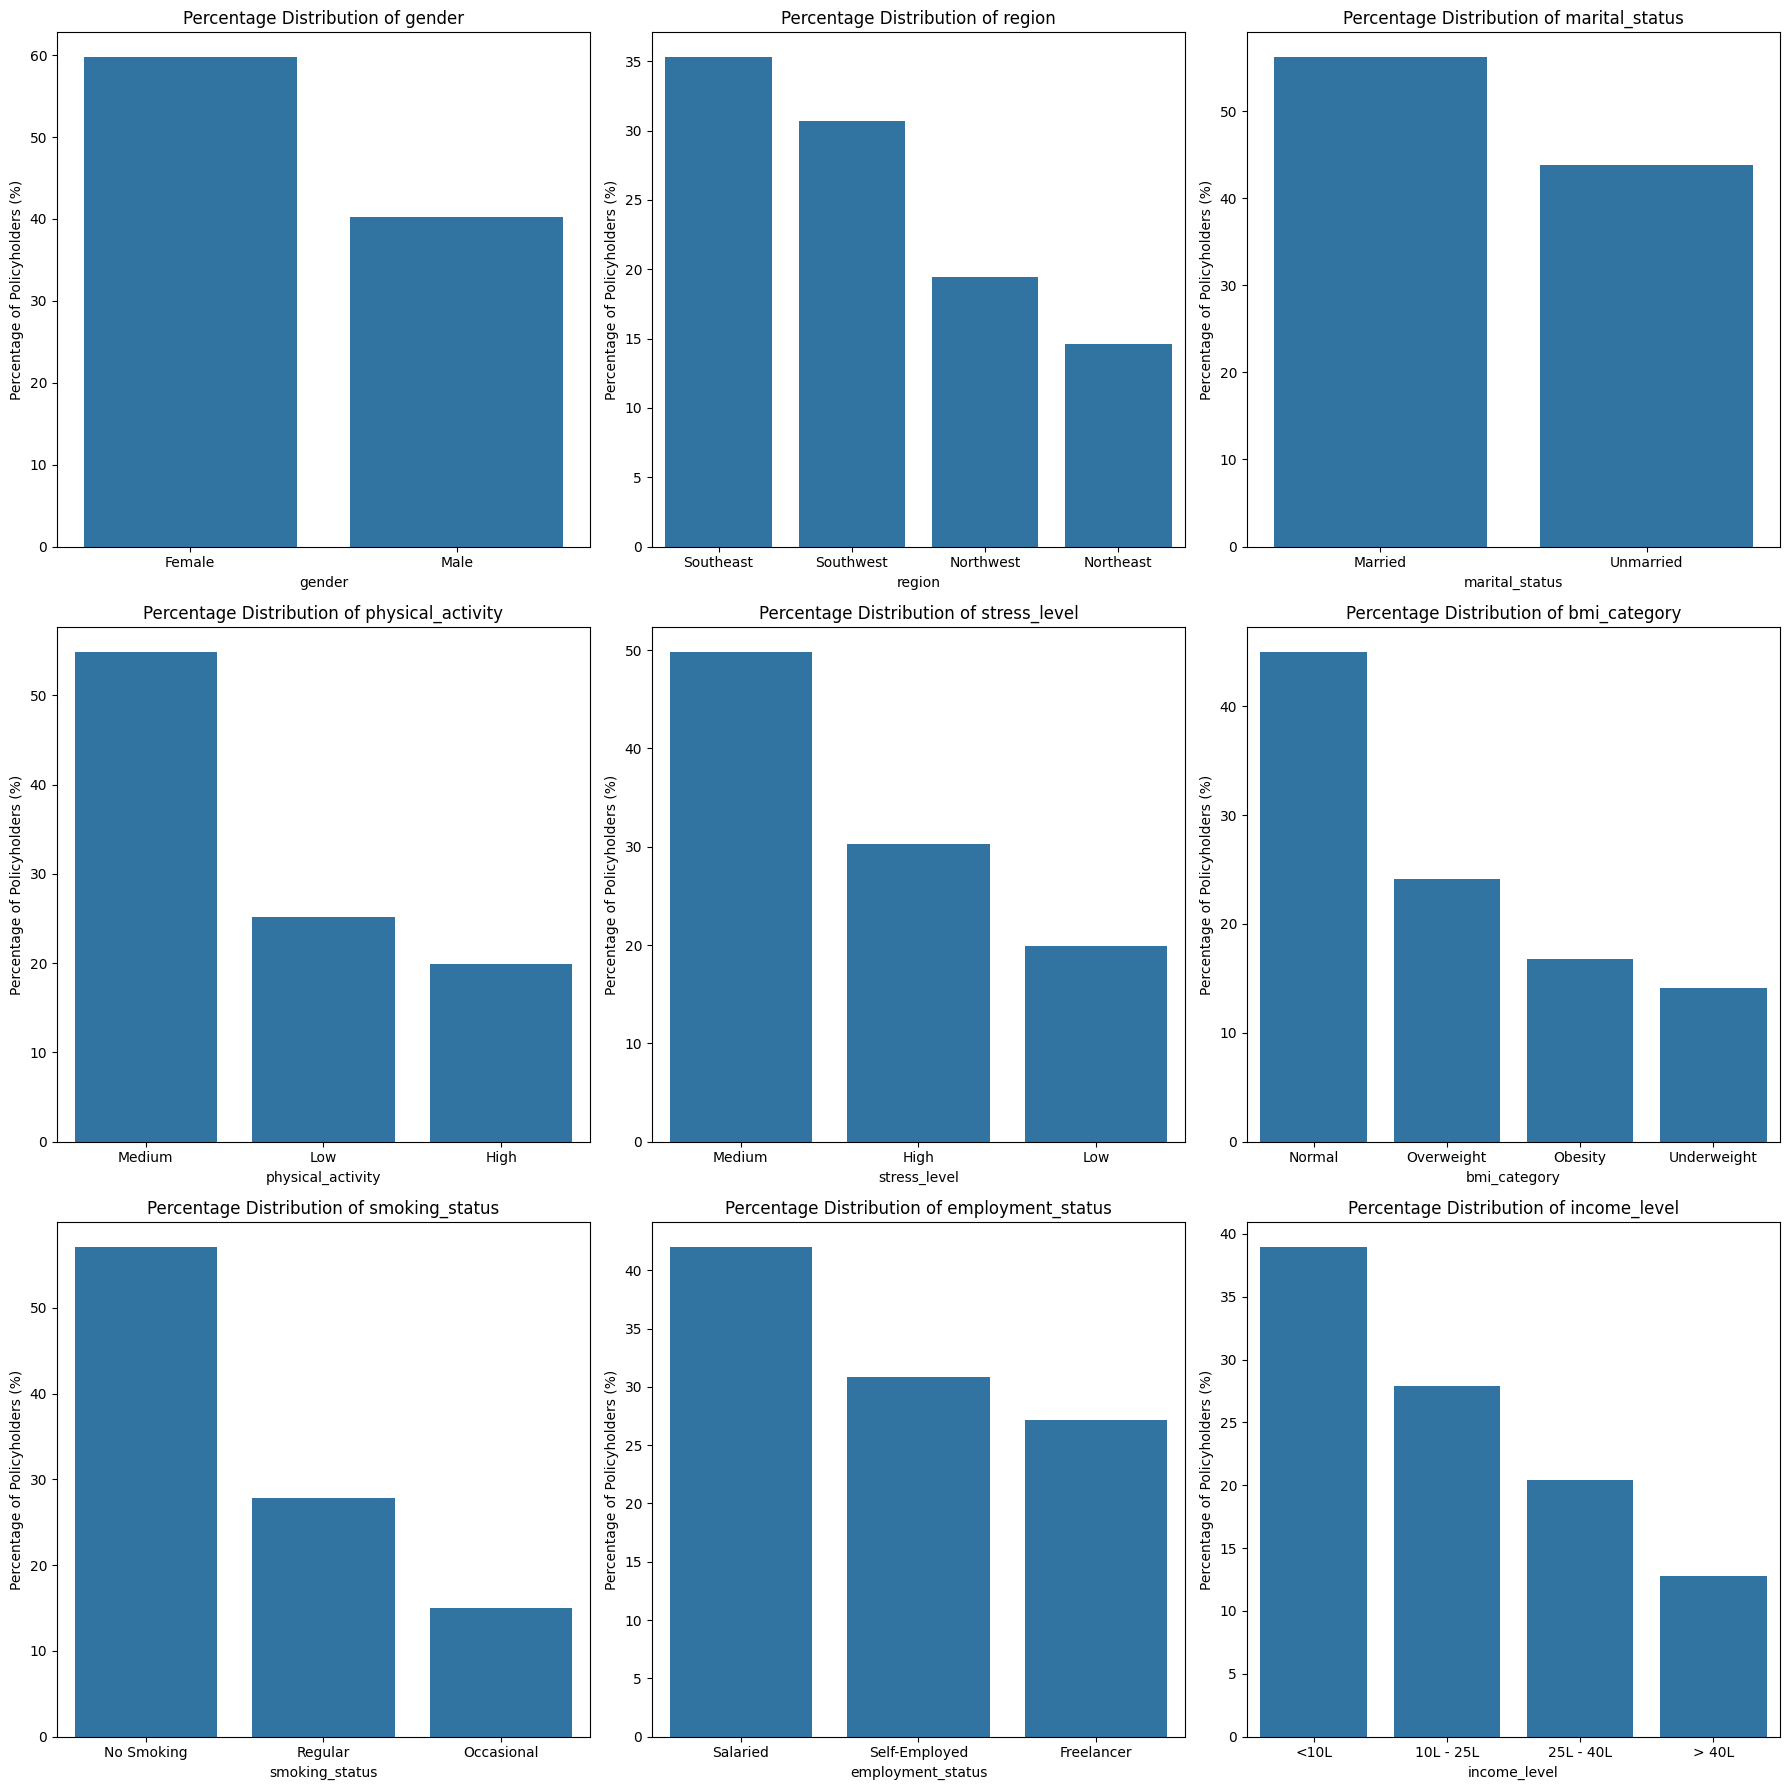

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(18, 18))  # Adjust figure size as necessary
axes = axes.flatten()  # Flatten the 2D array of axes into 1D for easier iteration

for ax, column in zip(axes, categorical_cols):
    # Calculate the percentage distribution of each category
    category_counts = df1[column].value_counts(normalize=True) * 100  # normalize=True gives the relative frequencies
    
    # Plotting the distribution using barplot
    sns.barplot(x=category_counts.index, y=category_counts.values, ax=ax)
    ax.set_title(f'Percentage Distribution of {column}')
    ax.set_ylabel('Percentage of Policyholders (%)')
    ax.set_xlabel(column)  # Set xlabel to the column name for clarity

plt.tight_layout()  # Adjusts plot parameters for better fit in the figure window
plt.show()

insurance_plan     1     2    3
income_level                   
1                533   733  733
2                822   998  909
3               2266  1366  184
4                 53   443  752


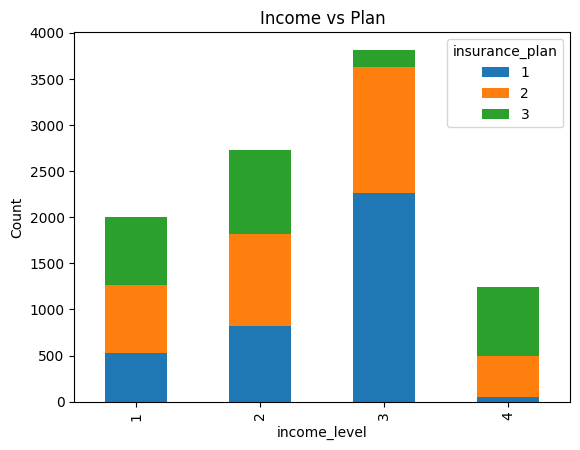

In [40]:
# Cross-tabulation of gender and smoking status
crosstab = pd.crosstab(df3['income_level'], df3['insurance_plan'])
print(crosstab)

# Plotting the crosstab
crosstab.plot(kind='bar', stacked=True)
plt.title('Income vs Plan')
plt.ylabel('Count')
plt.show()

<h2 align="center" style="color:blue">Feature Engineering</h2>

In [25]:
df1.medical_history.unique()

array(['High blood pressure', 'No Disease', 'Thyroid',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes', 'Heart disease', 'Diabetes & High blood pressure',
       'Diabetes & Heart disease'], dtype=object)

### Calculate Risk Score

In [26]:
risk_score = {
    'high blood pressure': 6,
    'no disease': 0,
    'heart disease': 8,
    'thyroid': 5,
    'diabetes': 6,
    'none': 0
}

# 🔹 Step 1: Clean medical_history
df1['medical_history'] = df1['medical_history'].str.lower().str.strip()

# 🔹 Step 2: Split into two diseases
df1[['disease1', 'disease2']] = df1['medical_history'].str.split('&', expand=True)

# 🔹 Step 3: Clean individual columns
df1['disease1'] = df1['disease1'].str.strip().fillna('none')
df1['disease2'] = df1['disease2'].str.strip().fillna('none')

# 🔹 Step 4: Calculate total risk score (SAFE)
df1['total_risk_score'] = (
    df1['disease1'].map(risk_score).fillna(0) +
    df1['disease2'].map(risk_score).fillna(0)
)

# 🔹 Step 5: Normalize score
max_score = df1['total_risk_score'].max()
min_score = df1['total_risk_score'].min()

# Avoid division by zero
if max_score != min_score:
    df1['normalized_risk_score'] = (
        (df1['total_risk_score'] - min_score) / (max_score - min_score)
    )
else:
    df1['normalized_risk_score'] = 0

# 🔹 Output
df1.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,25L - 40L,37,high blood pressure,Gold,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,10L - 25L,10,no disease,Silver,21108,no disease,none,0,0.000000


### Calculate LifeStyle Risk

In [43]:
def calculate_life_style_risk(row):
    physical_activity_risk_score = {
        "High": 0,
        "Medium": 1,
        "Low": 4
    }
    stress_risk_score = {
        "High": 4,
        "Medium": 1,
        "Low": 0
    }
    life_style_risk = physical_activity_risk_score[row['physical_activity']] + stress_risk_score[row['stress_level']]
    return life_style_risk

df1['lifestyle_risk_score'] = df1.apply(calculate_life_style_risk, axis=1)

<Axes: xlabel='lifestyle_risk_score', ylabel='Count'>

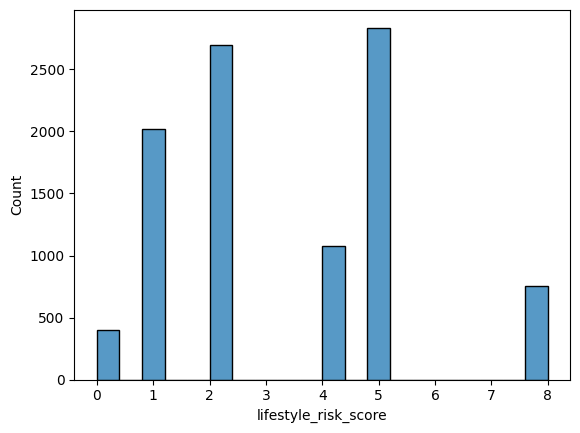

In [45]:
sns.histplot(df1.lifestyle_risk_score, bins=20)

### Encode text column

In [27]:
df1.income_level.unique()

array(['25L - 40L', '10L - 25L', '<10L', '> 40L'], dtype=object)

In [28]:
df1['income_level'] = df1['income_level'].map({
    '25L - 40L':1,
    '10L - 25L':2,
    '<10L':3,
    '> 40L':4
})
df1.head()

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,1,37,high blood pressure,Gold,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,2,10,no disease,Silver,21108,no disease,none,0,0.000000
2,18,Female,Southwest,Unmarried,Medium,High,0,Normal,No Smoking,Freelancer,3,9,no disease,Bronze,8459,no disease,none,0,0.000000
3,55,Male,Northeast,Married,High,Medium,3,Overweight,Occasional,Salaried,3,9,thyroid,Silver,21685,thyroid,none,5,0.357143
4,22,Male,Southeast,Unmarried,Medium,High,2,Normal,Regular,Self-Employed,2,13,high blood pressure & heart disease,Bronze,15984,high blood pressure,heart disease,14,1.000000


In [29]:
df1['insurance_plan'] = df1['insurance_plan'].map({
    'Bronze' : 1,
    'Silver' : 2,
    'Gold' : 3
})
df1.head(2)

,age,gender,region,marital_status,physical_activity,stress_level,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,normalized_risk_score
0,56,Female,Southeast,Unmarried,Medium,Medium,2,Normal,No Smoking,Self-Employed,1,37,high blood pressure,3,27944,high blood pressure,none,6,0.428571
1,38,Female,Northeast,Married,Low,High,5,Overweight,Occasional,Freelancer,2,10,no disease,2,21108,no disease,none,0,0.000000


In [30]:
nominal_col = ['gender','region','marital_status','physical_activity','stress_level','bmi_category','smoking_status','employment_status']
df2 = pd.get_dummies(df1,columns=nominal_col,drop_first=True,dtype=int)
df2.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease1,disease2,total_risk_score,...,physical_activity_Medium,stress_level_Low,stress_level_Medium,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,2,1,37,high blood pressure,3,27944,high blood pressure,none,6,...,1,0,1,0,0,0,0,0,0,1
1,38,5,2,10,no disease,2,21108,no disease,none,0,...,0,0,0,0,1,0,1,0,0,0
2,18,0,3,9,no disease,1,8459,no disease,none,0,...,1,0,0,0,0,0,0,0,0,0
3,55,3,3,9,thyroid,2,21685,thyroid,none,5,...,0,0,1,0,1,0,1,0,1,0
4,22,2,2,13,high blood pressure & heart disease,1,15984,high blood pressure,heart disease,14,...,1,0,0,0,0,0,0,1,0,1


### Feature Selection

In [31]:
df3 = df2.drop(columns=['medical_history','disease1','disease2','total_risk_score'],axis=1)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,...,physical_activity_Medium,stress_level_Low,stress_level_Medium,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,56,2,1,37,3,27944,0.428571,0,0,1,...,1,0,1,0,0,0,0,0,0,1
1,38,5,2,10,2,21108,0.000000,0,0,0,...,0,0,0,0,1,0,1,0,0,0
2,18,0,3,9,1,8459,0.000000,0,0,0,...,1,0,0,0,0,0,0,0,0,0
3,55,3,3,9,2,21685,0.357143,1,0,0,...,0,0,1,0,1,0,1,0,1,0
4,22,2,2,13,1,15984,1.000000,1,0,1,...,1,0,0,0,0,0,0,1,0,1


### Calculate VIF For Multicolinearity

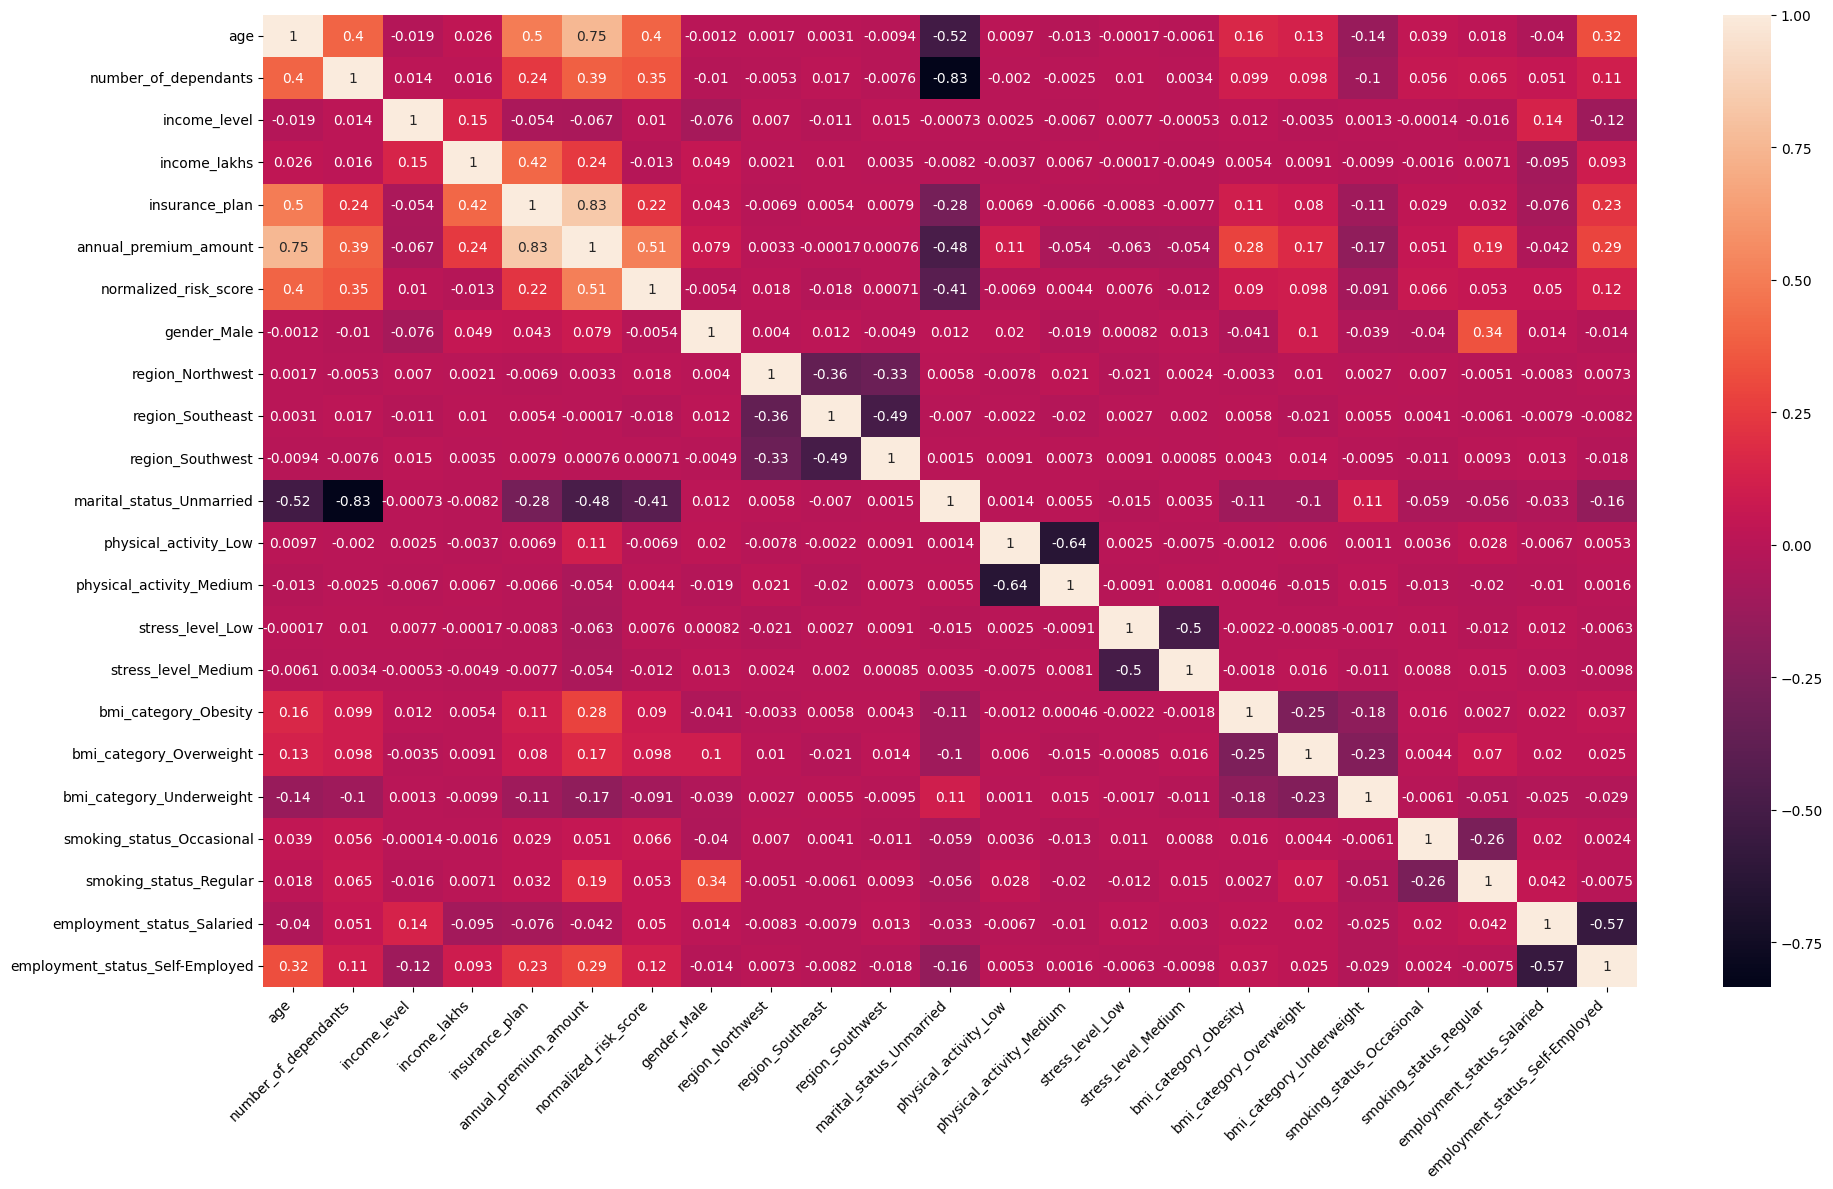

In [32]:
cm = df3.corr()
plt.figure(figsize=(20,12))
sns.heatmap(cm, annot=True)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
X = df3.drop('annual_premium_amount',axis=1)
y = df3['annual_premium_amount']

cols_to_scale = ['age','number_of_dependants','income_lakhs','income_level','insurance_plan']
scaler = MinMaxScaler()
X[cols_to_scale] = scaler.fit_transform(X[cols_to_scale])
X.describe()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalized_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,...,physical_activity_Medium,stress_level_Low,stress_level_Medium,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
count,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,...,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000,9792.000000
mean,0.365864,0.384109,0.480154,0.220502,0.444036,0.326411,0.402063,0.194138,0.353145,0.306781,...,0.548815,0.199244,0.498366,0.167688,0.241115,0.141136,0.150123,0.278697,0.420241,0.308211
std,0.258736,0.300574,0.317935,0.225310,0.395606,0.278950,0.490340,0.395556,0.477972,0.461181,...,0.497637,0.399452,0.500023,0.373608,0.427782,0.348179,0.357210,0.448381,0.493623,0.461778
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.111111,0.000000,0.333333,0.052083,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.351852,0.400000,0.666667,0.156250,0.500000,0.428571,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.592593,0.600000,0.666667,0.312500,1.000000,0.428571,1.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [34]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF']  = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df


In [35]:
calculate_vif(X)

,Column,VIF
0,age,5.597898
1,number_of_dependants,5.885174
2,income_level,3.385018
3,income_lakhs,2.633397
4,insurance_plan,3.937068
5,normalized_risk_score,3.014736
6,gender_Male,1.917075
7,region_Northwest,2.121935
8,region_Southeast,3.020835
9,region_Southwest,2.760752


### Model Training

#### Linear Regression

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(X_train,y_train)
model.score(X_test,y_test)

0.9561675818035242

#### Random Regression

In [37]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor()
rf_model.fit(X_train,y_train)
rf_model.score(X_test,y_test)

0.9874987666392602

### Feature Importance

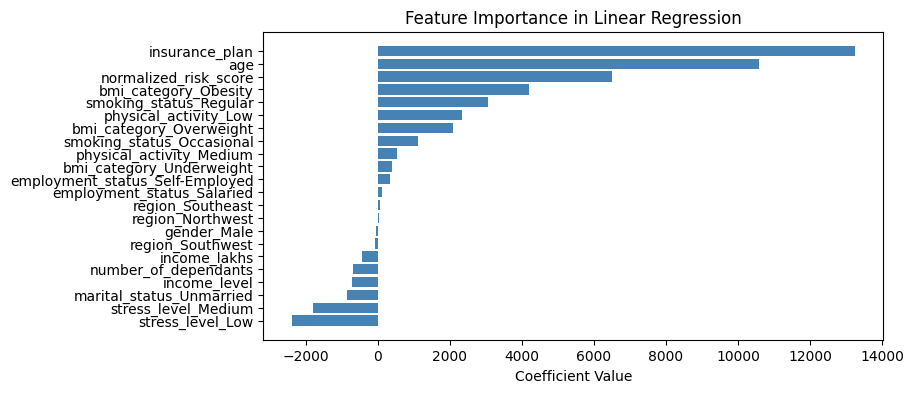

In [47]:
feature_importance = model.coef_

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Linear Regression')
plt.show()

#### XGBOOST Regressor

In [38]:
from xgboost import XGBRegressor
xg_model = XGBRegressor()
xg_model.fit(X_train,y_train)
xg_model.score(X_test,y_test)

0.993480384349823

In [39]:
import joblib as jb
jb.dump(xg_model,'model.pkl')

['model.pkl']